# Healthcare Analytics — EDA & Deeper Analysis
Notebook 02

This notebook performs comprehensive Exploratory Data Analysis across **five domains**:
1. **Patient Demographics** — Age, gender, race, geography, mortality
2. **Hospital Utilization** — Encounter patterns, LOS, readmissions, seasonality
3. **Financial & Payer Analysis** — Cost drivers, payer performance, out-of-pocket burden
4. **Chronic Disease Patterns** — Prevalence, comorbidities, onset age, disease trajectories
5. **Population Health** — Immunization coverage, care gaps, provider capacity

**Dataset:** Synthea synthetic healthcare data (1,171 patients, 53K+ encounters)


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
COLORS = sns.color_palette('muted', 10)
HIGHLIGHT = '#e74c3c'

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# Load all datasets
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) if os.path.exists('data/raw') else '.')
# Auto-detect project root
for p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(p, 'data/raw/patients.csv')):
        os.chdir(p)
        break
DATA_PATH = 'data/raw/'

patients      = pd.read_csv(f'{DATA_PATH}patients.csv')
encounters    = pd.read_csv(f'{DATA_PATH}encounters.csv')
conditions    = pd.read_csv(f'{DATA_PATH}conditions.csv')
medications   = pd.read_csv(f'{DATA_PATH}medications.csv')
observations  = pd.read_csv(f'{DATA_PATH}observations.csv')
procedures    = pd.read_csv(f'{DATA_PATH}procedures.csv')
immunizations = pd.read_csv(f'{DATA_PATH}immunizations.csv')
careplans     = pd.read_csv(f'{DATA_PATH}careplans.csv')
allergies     = pd.read_csv(f'{DATA_PATH}allergies.csv')
payers        = pd.read_csv(f'{DATA_PATH}payers.csv')
payer_trans   = pd.read_csv(f'{DATA_PATH}payer_transitions.csv')
organizations = pd.read_csv(f'{DATA_PATH}organizations.csv')
providers     = pd.read_csv(f'{DATA_PATH}providers.csv')

# Parse dates
for df, cols in [
    (patients,    ['BIRTHDATE', 'DEATHDATE']),
    (encounters,  ['START', 'STOP']),
    (conditions,  ['START', 'STOP']),
    (medications, ['START', 'STOP']),
]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

encounters['START'] = pd.to_datetime(encounters['START'], utc=True, errors='coerce')
encounters['STOP']  = pd.to_datetime(encounters['STOP'], utc=True, errors='coerce')

print(f"Loaded: {len(patients):,} patients | {len(encounters):,} encounters | "
      f"{len(conditions):,} conditions | {len(medications):,} medications | "
      f"{len(observations):,} observations")


Loaded: 1,171 patients | 53,346 encounters | 8,376 conditions | 42,989 medications | 299,697 observations


## 0.1 Feature Engineering

In [3]:
# Patient age (as of latest data point or death)
ref_date = pd.Timestamp('2020-04-01')
patients['AGE'] = patients.apply(
    lambda r: (r['DEATHDATE'] - r['BIRTHDATE']).days / 365.25
              if pd.notna(r['DEATHDATE'])
              else (ref_date - r['BIRTHDATE']).days / 365.25, axis=1
).astype(int)

patients['IS_ALIVE'] = patients['DEATHDATE'].isna()

patients['AGE_GROUP'] = pd.cut(patients['AGE'],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=['0-17', '18-34', '35-49', '50-64', '65-79', '80+'])

# Encounter duration in hours
encounters['DURATION_HRS'] = (
    encounters['STOP'] - encounters['START']
).dt.total_seconds() / 3600

# Encounter year/month
encounters['YEAR'] = encounters['START'].dt.year
encounters['MONTH'] = encounters['START'].dt.month
encounters['YEAR_MONTH'] = encounters['START'].dt.to_period('M')

# Patient out-of-pocket cost
encounters['OUT_OF_POCKET'] = encounters['TOTAL_CLAIM_COST'] - encounters['PAYER_COVERAGE']

# Condition active flag
conditions['IS_ACTIVE'] = conditions['STOP'].isna()

print("Feature engineering complete.")
print(f"  Patient age range: {patients['AGE'].min()} – {patients['AGE'].max()}")
print(f"  Encounter years: {encounters['YEAR'].min()} – {encounters['YEAR'].max()}")


Feature engineering complete.
  Patient age range: 0 – 110
  Encounter years: 1912 – 2020


---
## 1. Patient Demographics Analysis
Deep dive into the patient population: age distribution, gender, race/ethnicity, geographic spread, and mortality patterns.


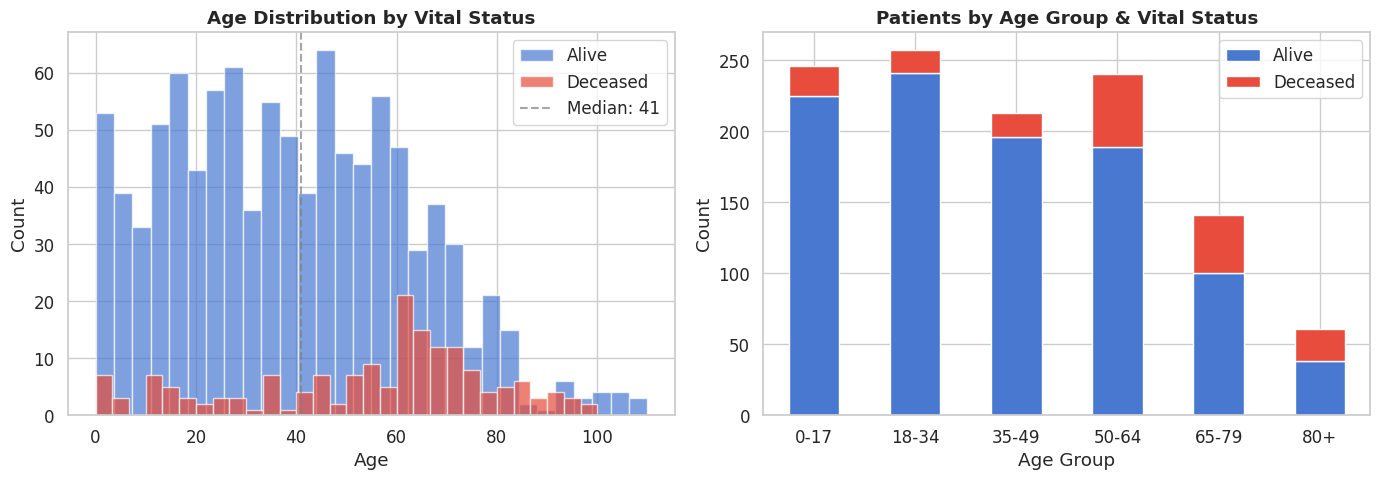

Median age: 41 | Mean: 41.1 | Std: 24.3
Alive: 1000 (85.4%) | Deceased: 171


In [4]:
# 1.1 Age Distribution with Alive/Deceased overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for status, color, label in [(True, COLORS[0], 'Alive'), (False, HIGHLIGHT, 'Deceased')]:
    subset = patients[patients['IS_ALIVE'] == status]
    axes[0].hist(subset['AGE'], bins=30, alpha=0.7, color=color, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Vital Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(patients['AGE'].median(), color='gray', linestyle='--', alpha=0.7, label=f"Median: {patients['AGE'].median():.0f}")
axes[0].legend()

# Age group bar
age_counts = patients.groupby(['AGE_GROUP', 'IS_ALIVE']).size().unstack(fill_value=0)
age_counts.columns = ['Deceased', 'Alive']
age_counts[['Alive', 'Deceased']].plot(kind='bar', stacked=True, ax=axes[1],
    color=[COLORS[0], HIGHLIGHT], edgecolor='white')
axes[1].set_title('Patients by Age Group & Vital Status')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('images/06_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"Median age: {patients['AGE'].median():.0f} | Mean: {patients['AGE'].mean():.1f} | Std: {patients['AGE'].std():.1f}")
print(f"Alive: {patients['IS_ALIVE'].sum()} ({patients['IS_ALIVE'].mean()*100:.1f}%) | Deceased: {(~patients['IS_ALIVE']).sum()}")


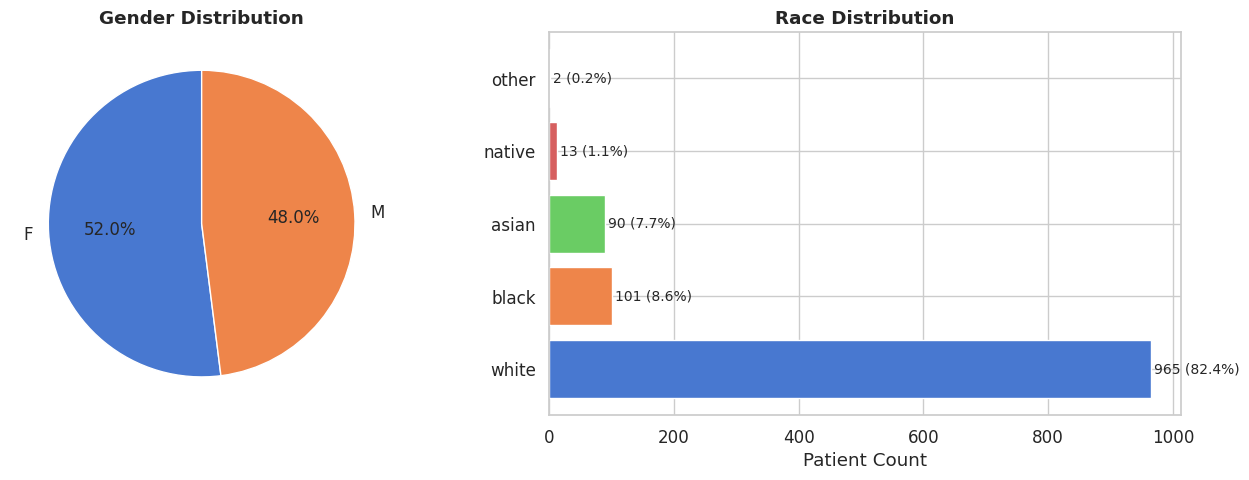

In [5]:
# 1.2 Gender & Race breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_counts = patients['GENDER'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[COLORS[0], COLORS[1]], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Gender Distribution')

# Race
race_counts = patients['RACE'].value_counts()
bars = axes[1].barh(race_counts.index, race_counts.values, color=COLORS[:len(race_counts)], edgecolor='white')
axes[1].set_title('Race Distribution')
axes[1].set_xlabel('Patient Count')
for bar, val in zip(bars, race_counts.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(patients)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/07_gender_race.png', dpi=150, bbox_inches='tight')
plt.show()


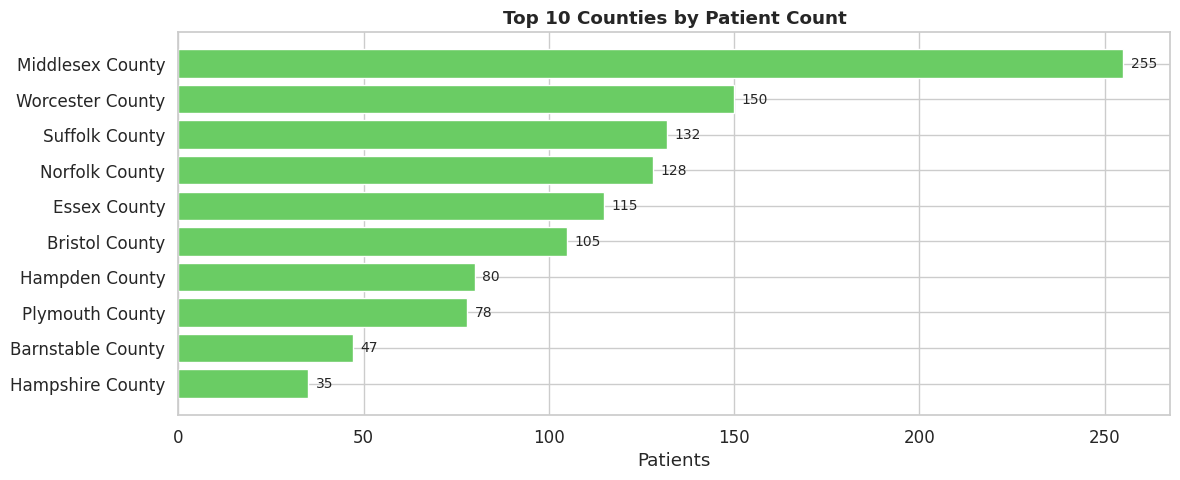

Patients span 1 state(s), 14 counties, 237 cities


In [6]:
# 1.3 Geographic distribution — top 10 counties
fig, ax = plt.subplots(figsize=(12, 5))
county_counts = patients['COUNTY'].value_counts().head(10)
bars = ax.barh(county_counts.index[::-1], county_counts.values[::-1], color=COLORS[2], edgecolor='white')
ax.set_title('Top 10 Counties by Patient Count')
ax.set_xlabel('Patients')
for bar, val in zip(bars, county_counts.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/08_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Patients span {patients['STATE'].nunique()} state(s), {patients['COUNTY'].nunique()} counties, {patients['CITY'].nunique()} cities")


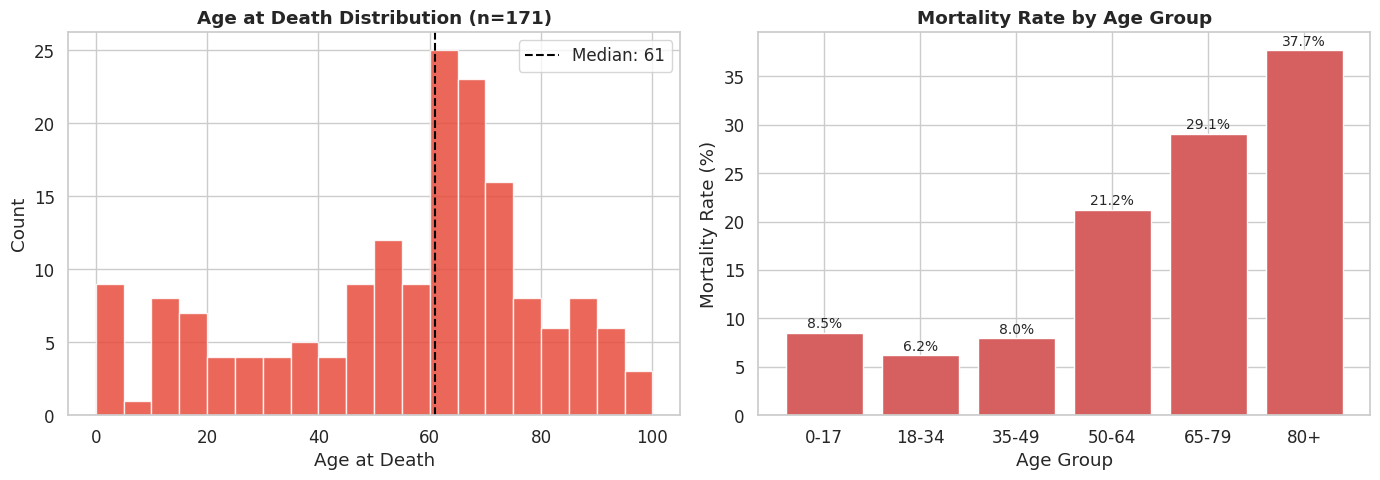

In [7]:
# 1.4 Mortality analysis — age at death distribution & mortality rate by age group
deceased = patients[~patients['IS_ALIVE']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(deceased['AGE'], bins=20, color=HIGHLIGHT, edgecolor='white', alpha=0.85)
axes[0].set_title(f'Age at Death Distribution (n={len(deceased)})')
axes[0].set_xlabel('Age at Death')
axes[0].set_ylabel('Count')
axes[0].axvline(deceased['AGE'].median(), color='black', linestyle='--', label=f"Median: {deceased['AGE'].median():.0f}")
axes[0].legend()

# Mortality rate by age group
mort = patients.groupby('AGE_GROUP').agg(
    total=('Id', 'count'),
    deceased=('IS_ALIVE', lambda x: (~x).sum())
).reset_index()
mort['mortality_rate'] = mort['deceased'] / mort['total'] * 100

axes[1].bar(mort['AGE_GROUP'].astype(str), mort['mortality_rate'], color=COLORS[3], edgecolor='white')
axes[1].set_title('Mortality Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mortality Rate (%)')
for i, row in mort.iterrows():
    axes[1].text(i, row['mortality_rate'] + 0.5, f"{row['mortality_rate']:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/09_mortality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Hospital Utilization Analysis
Encounter volume, class distribution, length of stay, readmission patterns, and seasonality.


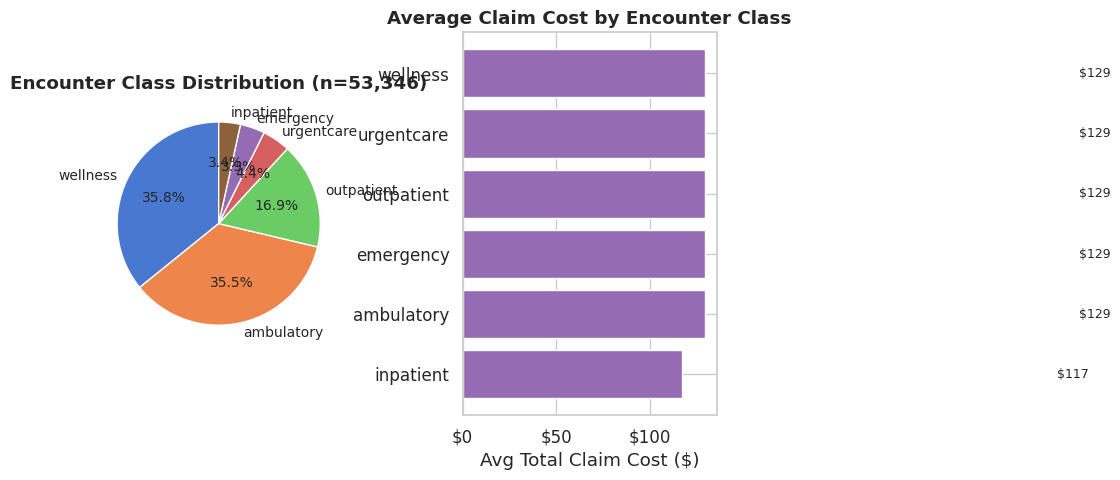

In [8]:
# 2.1 Encounter class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

enc_class = encounters['ENCOUNTERCLASS'].value_counts()
axes[0].pie(enc_class, labels=enc_class.index, autopct='%1.1f%%',
            colors=COLORS[:len(enc_class)], startangle=90, textprops={'fontsize': 10})
axes[0].set_title(f'Encounter Class Distribution (n={len(encounters):,})')

# Average cost by class
cost_by_class = encounters.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].mean().sort_values(ascending=True)
bars = axes[1].barh(cost_by_class.index, cost_by_class.values, color=COLORS[4], edgecolor='white')
axes[1].set_title('Average Claim Cost by Encounter Class')
axes[1].set_xlabel('Avg Total Claim Cost ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, cost_by_class.values):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/10_encounter_class.png', dpi=150, bbox_inches='tight')
plt.show()


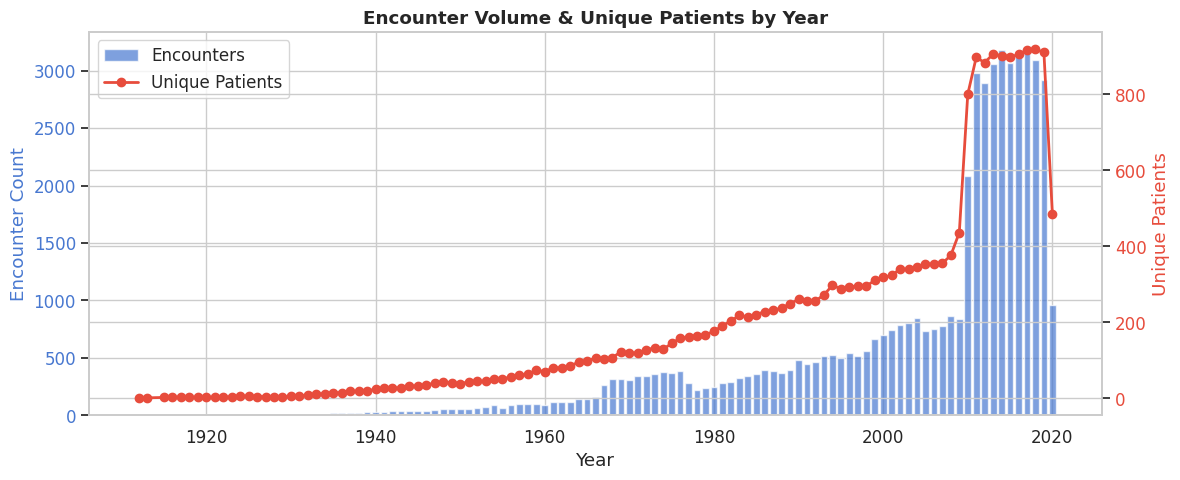

In [9]:
# 2.2 Encounter volume trend over time (yearly)
yearly = encounters.groupby('YEAR').agg(
    total_encounters=('Id', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    total_cost=('TOTAL_CLAIM_COST', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(yearly['YEAR'], yearly['total_encounters'], color=COLORS[0], alpha=0.7, label='Encounters')
ax1.set_xlabel('Year')
ax1.set_ylabel('Encounter Count', color=COLORS[0])
ax1.tick_params(axis='y', labelcolor=COLORS[0])

ax2 = ax1.twinx()
ax2.plot(yearly['YEAR'], yearly['unique_patients'], color=HIGHLIGHT, marker='o', linewidth=2, label='Unique Patients')
ax2.set_ylabel('Unique Patients', color=HIGHLIGHT)
ax2.tick_params(axis='y', labelcolor=HIGHLIGHT)

ax1.set_title('Encounter Volume & Unique Patients by Year')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('images/11_encounter_trend.png', dpi=150, bbox_inches='tight')
plt.show()


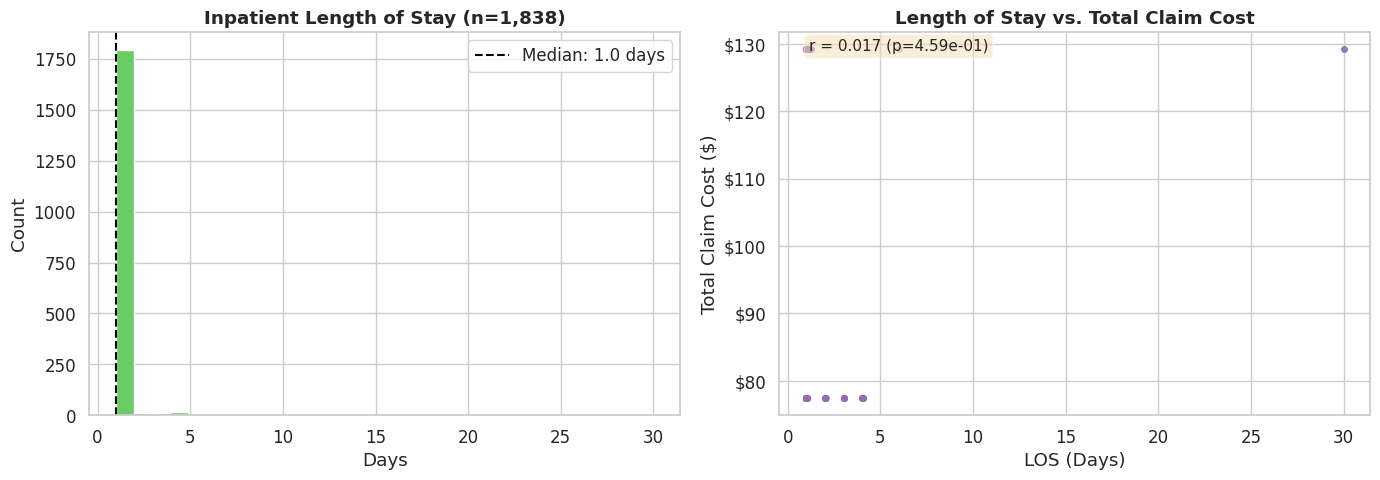

Inpatient LOS — Mean: 18.0 days | Median: 1.0 | Max: 20215.2


In [10]:
# 2.3 Length of Stay analysis (inpatient only)
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()
inpatient['LOS_DAYS'] = inpatient['DURATION_HRS'] / 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOS distribution
axes[0].hist(inpatient['LOS_DAYS'].clip(upper=30), bins=30, color=COLORS[2], edgecolor='white')
axes[0].set_title(f'Inpatient Length of Stay (n={len(inpatient):,})')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].axvline(inpatient['LOS_DAYS'].median(), color='black', linestyle='--',
                label=f"Median: {inpatient['LOS_DAYS'].median():.1f} days")
axes[0].legend()

# LOS vs Cost scatter
axes[1].scatter(inpatient['LOS_DAYS'].clip(upper=30), inpatient['TOTAL_CLAIM_COST'],
                alpha=0.4, s=15, color=COLORS[4])
axes[1].set_title('Length of Stay vs. Total Claim Cost')
axes[1].set_xlabel('LOS (Days)')
axes[1].set_ylabel('Total Claim Cost ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Correlation
r, p = stats.pearsonr(inpatient['LOS_DAYS'].dropna(), inpatient.loc[inpatient['LOS_DAYS'].notna(), 'TOTAL_CLAIM_COST'])
axes[1].annotate(f'r = {r:.3f} (p={p:.2e})', xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('images/12_length_of_stay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Inpatient LOS — Mean: {inpatient['LOS_DAYS'].mean():.1f} days | "
      f"Median: {inpatient['LOS_DAYS'].median():.1f} | Max: {inpatient['LOS_DAYS'].max():.1f}")


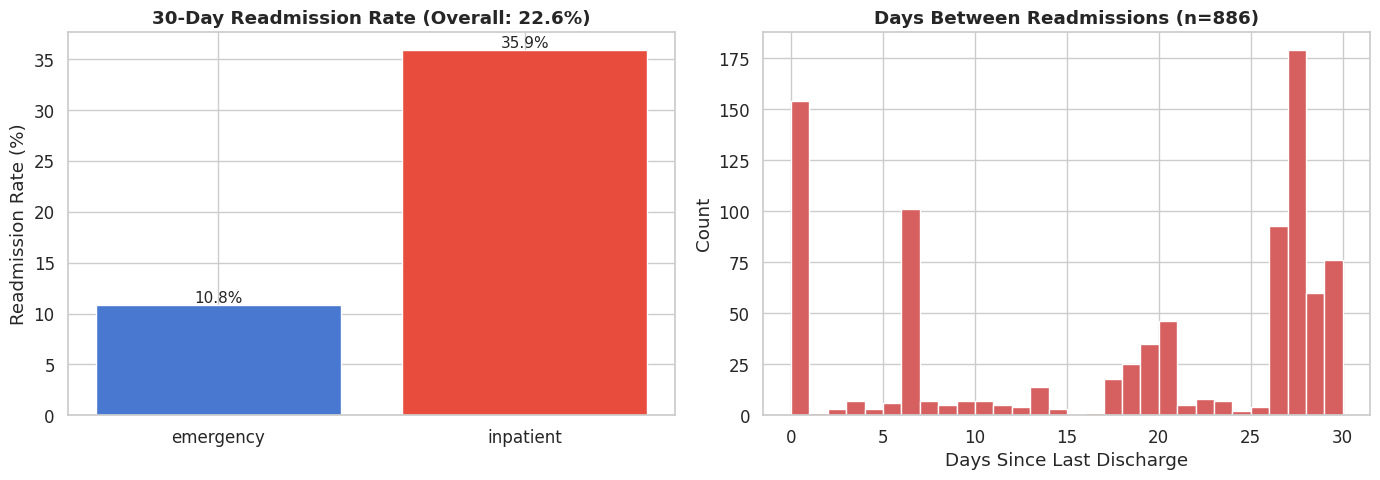

Total 30-day readmissions: 886 / 3,928 acute encounters


In [11]:
# 2.4  30-Day Readmission Analysis
acute = encounters[encounters['ENCOUNTERCLASS'].isin(['inpatient', 'emergency'])].sort_values(['PATIENT', 'START'])
acute['PREV_DISCHARGE'] = acute.groupby('PATIENT')['STOP'].shift(1)
acute['DAYS_SINCE_LAST'] = (acute['START'] - acute['PREV_DISCHARGE']).dt.total_seconds() / 86400
acute['IS_READMIT_30'] = (acute['DAYS_SINCE_LAST'] >= 0) & (acute['DAYS_SINCE_LAST'] <= 30)

readmit_rate = acute['IS_READMIT_30'].mean() * 100
readmit_by_class = acute.groupby('ENCOUNTERCLASS')['IS_READMIT_30'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Readmission rate by class
bars = axes[0].bar(readmit_by_class.index, readmit_by_class.values,
                   color=[COLORS[0], HIGHLIGHT], edgecolor='white')
axes[0].set_title(f'30-Day Readmission Rate (Overall: {readmit_rate:.1f}%)')
axes[0].set_ylabel('Readmission Rate (%)')
for bar, val in zip(bars, readmit_by_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=11)

# Days between encounters distribution (readmissions only)
readmits = acute[acute['IS_READMIT_30']]
axes[1].hist(readmits['DAYS_SINCE_LAST'], bins=30, color=COLORS[3], edgecolor='white')
axes[1].set_title(f'Days Between Readmissions (n={len(readmits):,})')
axes[1].set_xlabel('Days Since Last Discharge')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('images/13_readmissions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total 30-day readmissions: {acute['IS_READMIT_30'].sum():,} / {len(acute):,} acute encounters")


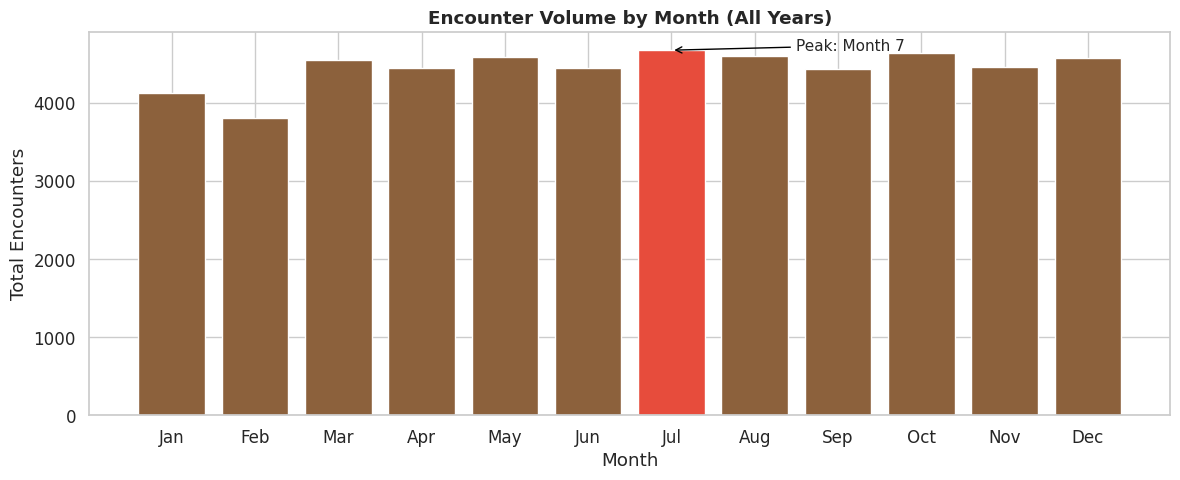

In [12]:
# 2.5 Seasonality — encounters by month
fig, ax = plt.subplots(figsize=(12, 5))
monthly = encounters.groupby('MONTH').size()
ax.bar(monthly.index, monthly.values, color=COLORS[5], edgecolor='white')
ax.set_title('Encounter Volume by Month (All Years)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Encounters')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

# Highlight peak
peak_month = monthly.idxmax()
ax.patches[peak_month - 1].set_facecolor(HIGHLIGHT)
ax.annotate(f'Peak: Month {peak_month}', xy=(peak_month, monthly.max()),
            xytext=(peak_month + 1.5, monthly.max()),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

plt.tight_layout()
plt.savefig('images/14_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Financial & Payer Analysis
Cost distributions, payer performance, out-of-pocket burden, and cost trends.


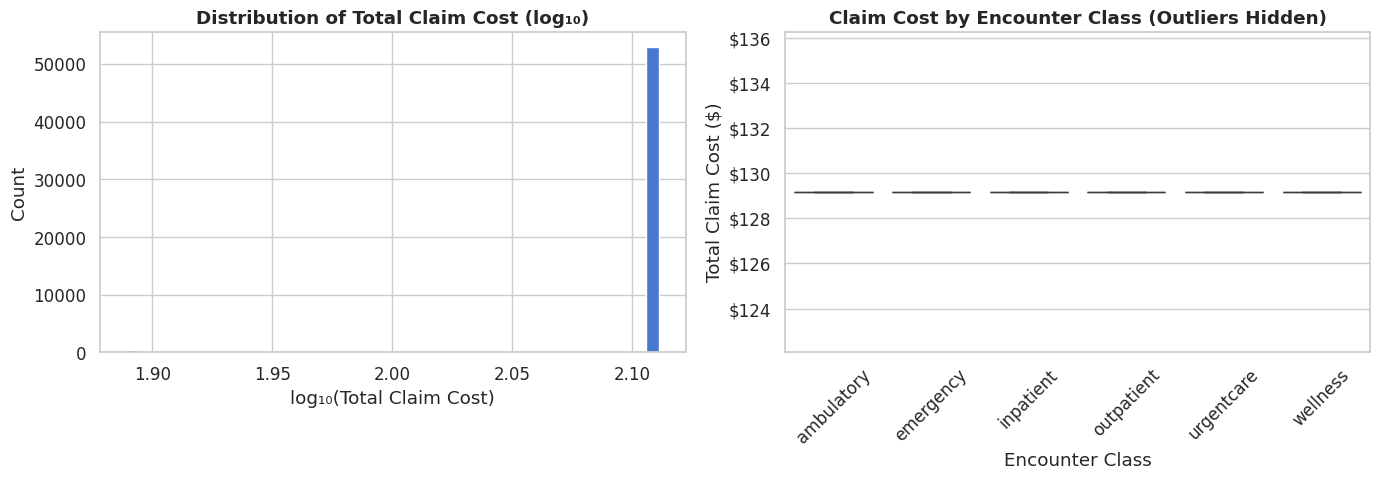

Total billed: $6,868,313
Median encounter cost: $129.16
Top 5% of encounters account for $344,470 (5.0% of total)


In [13]:
# 3.1 Total cost distribution (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost distribution
enc_costs = encounters[encounters['TOTAL_CLAIM_COST'] > 0]['TOTAL_CLAIM_COST']
axes[0].hist(np.log10(enc_costs), bins=40, color=COLORS[0], edgecolor='white')
axes[0].set_title('Distribution of Total Claim Cost (log₁₀)')
axes[0].set_xlabel('log₁₀(Total Claim Cost)')
axes[0].set_ylabel('Count')

# Box plot by encounter class
class_order = encounters.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].median().sort_values().index
encounters_plot = encounters[encounters['TOTAL_CLAIM_COST'] > 0]
sns.boxplot(data=encounters_plot, x='ENCOUNTERCLASS', y='TOTAL_CLAIM_COST',
            order=class_order, ax=axes[1], palette='muted', showfliers=False)
axes[1].set_title('Claim Cost by Encounter Class (Outliers Hidden)')
axes[1].set_xlabel('Encounter Class')
axes[1].set_ylabel('Total Claim Cost ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/15_cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total billed: ${encounters['TOTAL_CLAIM_COST'].sum():,.0f}")
print(f"Median encounter cost: ${encounters['TOTAL_CLAIM_COST'].median():,.2f}")
print(f"Top 5% of encounters account for ${encounters.nlargest(int(len(encounters)*0.05), 'TOTAL_CLAIM_COST')['TOTAL_CLAIM_COST'].sum():,.0f} "
      f"({encounters.nlargest(int(len(encounters)*0.05), 'TOTAL_CLAIM_COST')['TOTAL_CLAIM_COST'].sum()/encounters['TOTAL_CLAIM_COST'].sum()*100:.1f}% of total)")


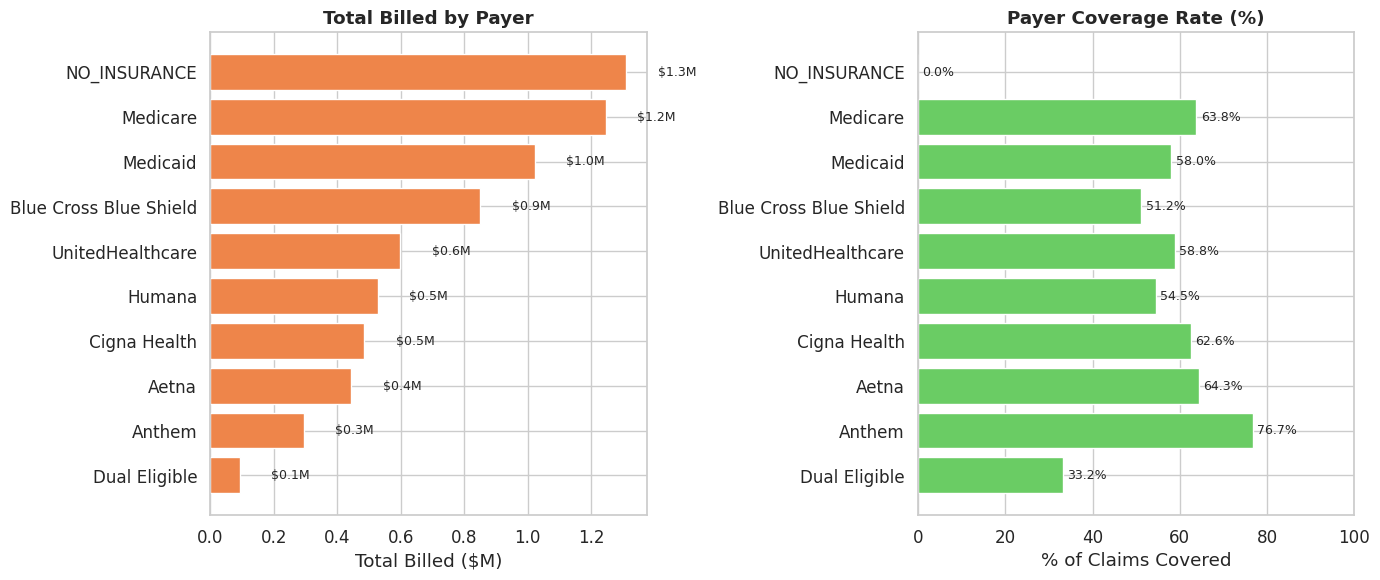

                  NAME  encounters  unique_patients  total_billed  coverage_pct
          NO_INSURANCE       10175              693    1310431.09           0.0
              Medicare        9645              193    1245644.86          63.8
              Medicaid        7966              415    1021809.77          58.0
Blue Cross Blue Shield        6604              262     850699.16          51.2
      UnitedHealthcare        4654              260     598630.48          58.8
                Humana        4115              235     526843.10          54.5
          Cigna Health        3766              244     485641.51          62.6
                 Aetna        3433              240     442837.91          64.3
                Anthem        2273              210     293580.68          76.7
         Dual Eligible         715               24      92194.39          33.2


In [14]:
# 3.2 Payer performance comparison
enc_payer = encounters.merge(payers[['Id', 'NAME']], left_on='PAYER', right_on='Id', suffixes=('', '_PAYER'))

payer_stats = enc_payer.groupby('NAME').agg(
    encounters=('Id', 'count'),
    total_billed=('TOTAL_CLAIM_COST', 'sum'),
    total_covered=('PAYER_COVERAGE', 'sum'),
    avg_cost=('TOTAL_CLAIM_COST', 'mean'),
    unique_patients=('PATIENT', 'nunique')
).reset_index()
payer_stats['coverage_pct'] = (payer_stats['total_covered'] / payer_stats['total_billed'] * 100).round(1)
payer_stats = payer_stats.sort_values('total_billed', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total billed by payer
bars = axes[0].barh(payer_stats['NAME'][::-1], payer_stats['total_billed'][::-1] / 1e6,
                     color=COLORS[1], edgecolor='white')
axes[0].set_title('Total Billed by Payer')
axes[0].set_xlabel('Total Billed ($M)')
for bar, val in zip(bars, payer_stats['total_billed'][::-1] / 1e6):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=9)

# Coverage percentage
bars2 = axes[1].barh(payer_stats['NAME'][::-1], payer_stats['coverage_pct'][::-1],
                      color=COLORS[2], edgecolor='white')
axes[1].set_title('Payer Coverage Rate (%)')
axes[1].set_xlabel('% of Claims Covered')
axes[1].set_xlim(0, 100)
for bar, val in zip(bars2, payer_stats['coverage_pct'][::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/16_payer_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(payer_stats[['NAME', 'encounters', 'unique_patients', 'total_billed', 'coverage_pct']].to_string(index=False))


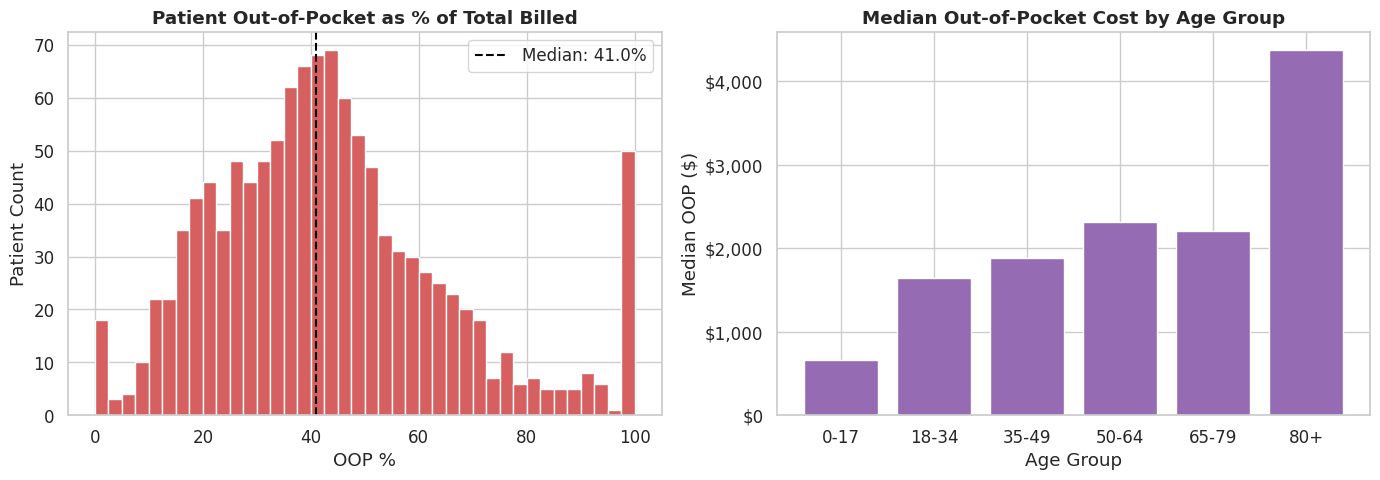

Median patient lifetime OOP: $1,550
Top 10% OOP threshold: $5,898


In [15]:
# 3.3 Out-of-Pocket burden analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Patient-level total OOP
patient_oop = encounters.groupby('PATIENT').agg(
    total_oop=('OUT_OF_POCKET', 'sum'),
    total_billed=('TOTAL_CLAIM_COST', 'sum'),
    encounter_count=('Id', 'count')
).reset_index()
patient_oop = patient_oop.merge(patients[['Id', 'AGE_GROUP', 'GENDER']], left_on='PATIENT', right_on='Id')
patient_oop['oop_pct'] = (patient_oop['total_oop'] / patient_oop['total_billed'] * 100).clip(0, 100)

axes[0].hist(patient_oop['oop_pct'], bins=40, color=COLORS[3], edgecolor='white')
axes[0].set_title('Patient Out-of-Pocket as % of Total Billed')
axes[0].set_xlabel('OOP %')
axes[0].set_ylabel('Patient Count')
axes[0].axvline(patient_oop['oop_pct'].median(), color='black', linestyle='--',
                label=f"Median: {patient_oop['oop_pct'].median():.1f}%")
axes[0].legend()

# OOP by age group
oop_age = patient_oop.groupby('AGE_GROUP')['total_oop'].median()
axes[1].bar(oop_age.index.astype(str), oop_age.values, color=COLORS[4], edgecolor='white')
axes[1].set_title('Median Out-of-Pocket Cost by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Median OOP ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('images/17_oop_burden.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median patient lifetime OOP: ${patient_oop['total_oop'].median():,.0f}")
print(f"Top 10% OOP threshold: ${patient_oop['total_oop'].quantile(0.9):,.0f}")


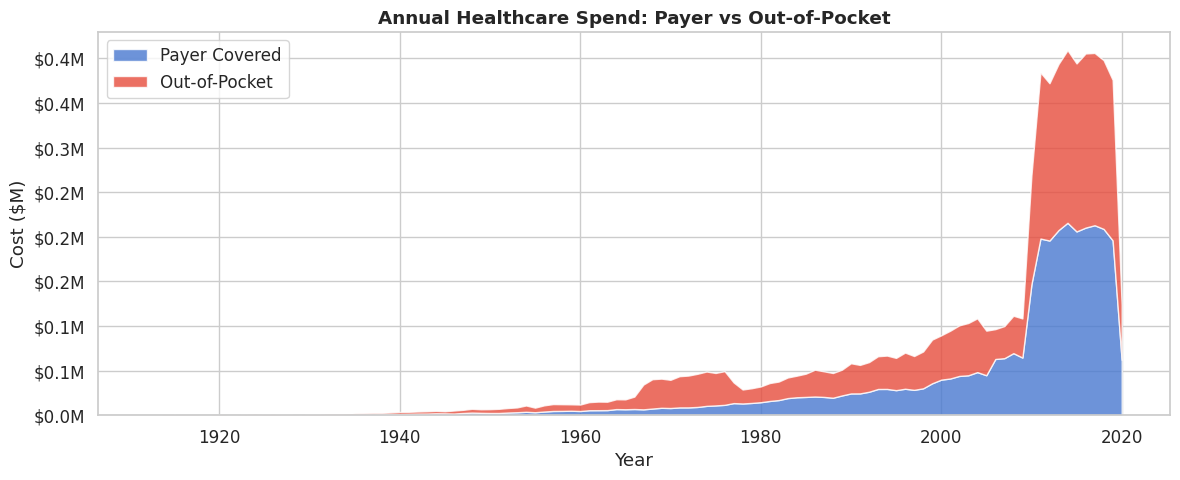

In [16]:
# 3.4 Cost trend — YoY total spend
yearly_cost = encounters.groupby('YEAR').agg(
    total_cost=('TOTAL_CLAIM_COST', 'sum'),
    total_covered=('PAYER_COVERAGE', 'sum'),
    total_oop=('OUT_OF_POCKET', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(yearly_cost['YEAR'], yearly_cost['total_covered']/1e6,
             yearly_cost['total_oop']/1e6,
             labels=['Payer Covered', 'Out-of-Pocket'],
             colors=[COLORS[0], HIGHLIGHT], alpha=0.8)
ax.set_title('Annual Healthcare Spend: Payer vs Out-of-Pocket')
ax.set_xlabel('Year')
ax.set_ylabel('Cost ($M)')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.savefig('images/18_cost_trend.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Chronic Disease Patterns
Prevalence of chronic conditions, comorbidity analysis, age of onset, and disease trajectories.


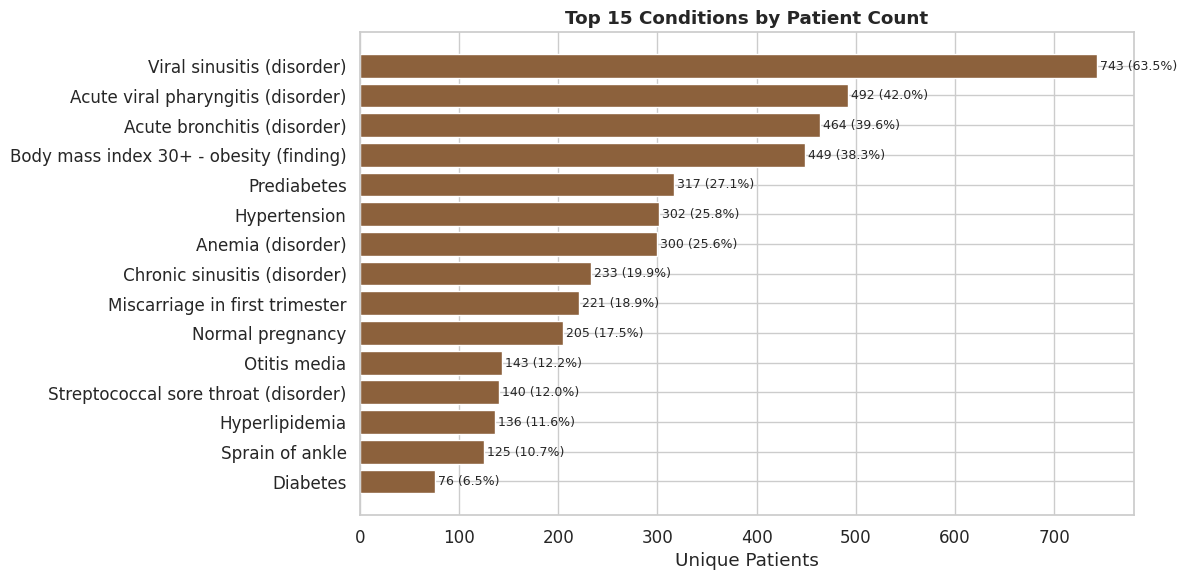

In [17]:
# 4.1 Top 15 conditions by prevalence
cond_counts = conditions.groupby('DESCRIPTION')['PATIENT'].nunique().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cond_counts.index[::-1], cond_counts.values[::-1], color=COLORS[5], edgecolor='white')
ax.set_title('Top 15 Conditions by Patient Count')
ax.set_xlabel('Unique Patients')
for bar, val in zip(bars, cond_counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(patients)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/19_top_conditions.png', dpi=150, bbox_inches='tight')
plt.show()


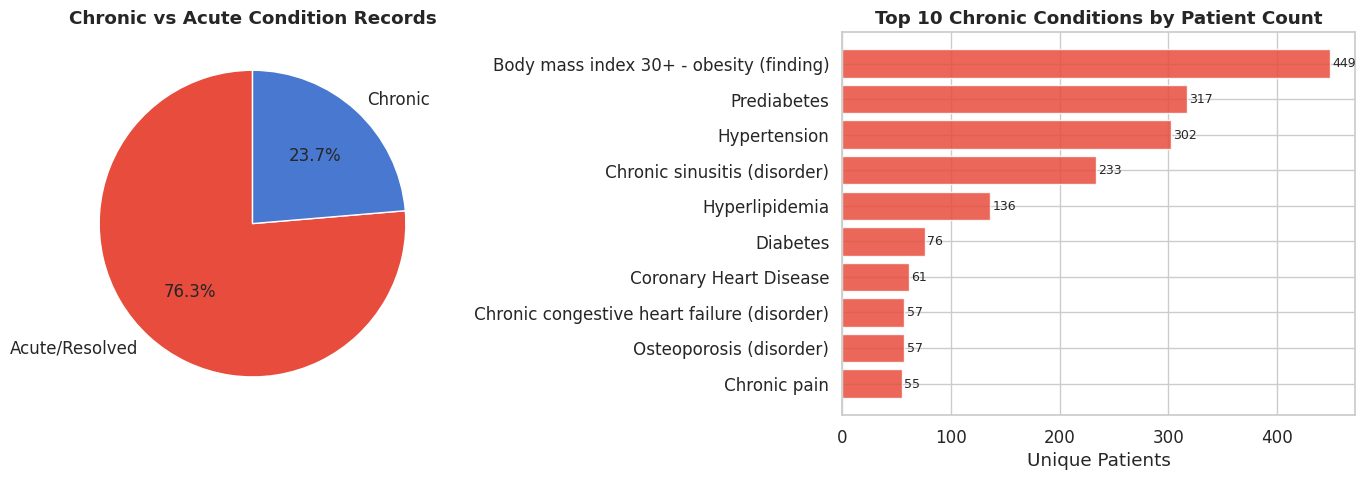

Chronic condition records: 1,982 (23.7%)
Patients with ≥1 chronic condition: 839


In [18]:
# 4.2 Chronic vs Resolved conditions
chronic_keywords = ['diabetes', 'hypertension', 'hyperlipidemia', 'obesity', 'asthma', 
                    'copd', 'heart failure', 'coronary', 'chronic', 'prediabetes',
                    'alzheimer', 'osteoporosis', 'fibromyalgia', 'lupus', 'rheumatoid']

conditions['IS_CHRONIC'] = conditions['DESCRIPTION'].str.lower().apply(
    lambda x: any(kw in x for kw in chronic_keywords)
)

chronic_summary = conditions.groupby('IS_CHRONIC').agg(
    records=('PATIENT', 'count'),
    unique_patients=('PATIENT', 'nunique'),
    active=('IS_ACTIVE', 'sum')
).reset_index()
chronic_summary['IS_CHRONIC'] = chronic_summary['IS_CHRONIC'].map({True: 'Chronic', False: 'Acute/Resolved'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(chronic_summary['records'], labels=chronic_summary['IS_CHRONIC'],
            autopct='%1.1f%%', colors=[HIGHLIGHT, COLORS[0]], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Chronic vs Acute Condition Records')

# Top chronic conditions
chronic_top = conditions[conditions['IS_CHRONIC']].groupby('DESCRIPTION')['PATIENT'].nunique().sort_values(ascending=False).head(10)
axes[1].barh(chronic_top.index[::-1], chronic_top.values[::-1], color=HIGHLIGHT, edgecolor='white', alpha=0.85)
axes[1].set_title('Top 10 Chronic Conditions by Patient Count')
axes[1].set_xlabel('Unique Patients')
for i, (idx, val) in enumerate(zip(chronic_top.index[::-1], chronic_top.values[::-1])):
    axes[1].text(val + 2, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/20_chronic_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chronic condition records: {conditions['IS_CHRONIC'].sum():,} ({conditions['IS_CHRONIC'].mean()*100:.1f}%)")
print(f"Patients with ≥1 chronic condition: {conditions[conditions['IS_CHRONIC']]['PATIENT'].nunique()}")


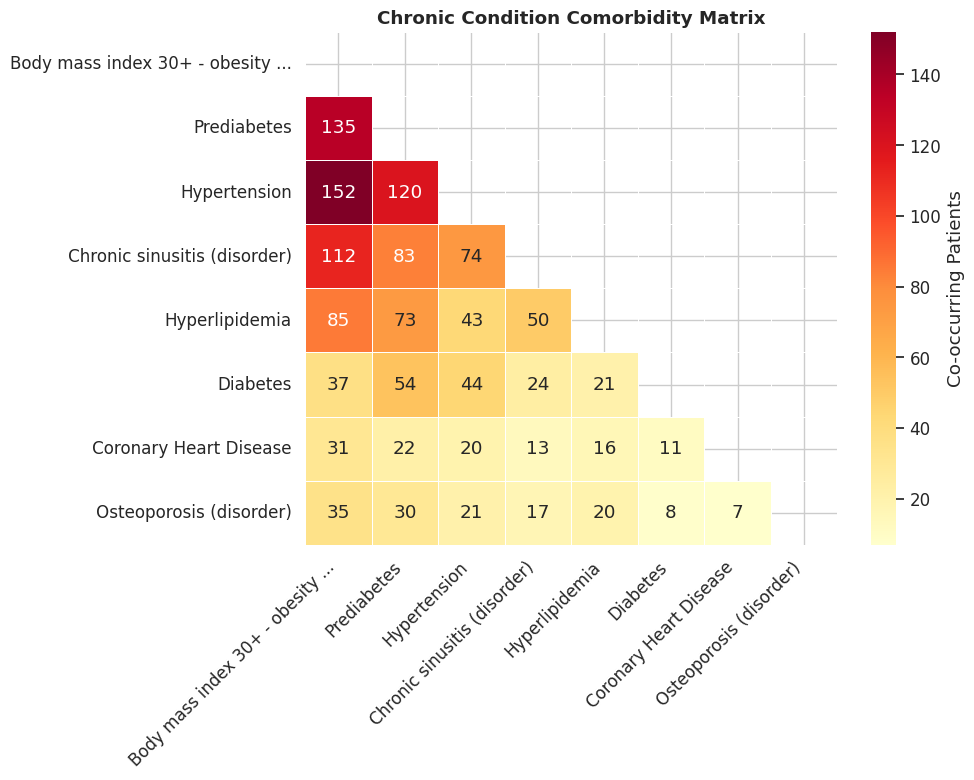

In [19]:
# 4.3 Comorbidity analysis — which chronic conditions co-occur?
chronic_pts = conditions[conditions['IS_CHRONIC']][['PATIENT', 'DESCRIPTION']].drop_duplicates()
patient_conditions = chronic_pts.groupby('PATIENT')['DESCRIPTION'].apply(list).reset_index()

# Build co-occurrence matrix for top 8 chronic conditions
top_chronic = chronic_pts['DESCRIPTION'].value_counts().head(8).index.tolist()
comorbidity = pd.DataFrame(0, index=top_chronic, columns=top_chronic)

for _, row in patient_conditions.iterrows():
    conds = [c for c in row['DESCRIPTION'] if c in top_chronic]
    for i in range(len(conds)):
        for j in range(i+1, len(conds)):
            comorbidity.loc[conds[i], conds[j]] += 1
            comorbidity.loc[conds[j], conds[i]] += 1

# Short labels for readability
short_labels = [c[:30] + '...' if len(c) > 30 else c for c in top_chronic]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(comorbidity, dtype=bool), k=0)
sns.heatmap(comorbidity, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=short_labels, yticklabels=short_labels, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Co-occurring Patients'})
ax.set_title('Chronic Condition Comorbidity Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/21_comorbidity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


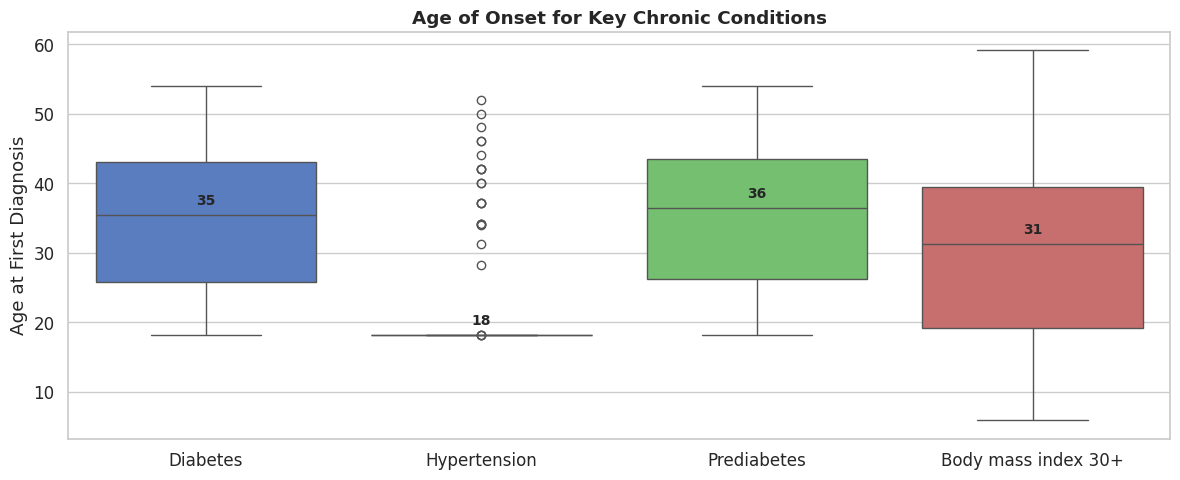

In [20]:
# 4.4 Age of onset for key chronic conditions
key_chronic = ['Diabetes', 'Hypertension', 'Prediabetes', 'Body mass index 30+']
onset_data = []

for kw in key_chronic:
    subset = conditions[conditions['DESCRIPTION'].str.contains(kw, case=False, na=False)]
    first_dx = subset.sort_values('START').groupby('PATIENT').first().reset_index()
    first_dx = first_dx.merge(patients[['Id', 'BIRTHDATE']], left_on='PATIENT', right_on='Id')
    first_dx['ONSET_AGE'] = (first_dx['START'] - first_dx['BIRTHDATE']).dt.days / 365.25
    for _, r in first_dx.iterrows():
        onset_data.append({'Condition': kw, 'Onset_Age': r['ONSET_AGE']})

onset_df = pd.DataFrame(onset_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=onset_df, x='Condition', y='Onset_Age', palette='muted', ax=ax)
ax.set_title('Age of Onset for Key Chronic Conditions')
ax.set_ylabel('Age at First Diagnosis')
ax.set_xlabel('')

# Add median annotations
medians = onset_df.groupby('Condition')['Onset_Age'].median()
for i, cond in enumerate(ax.get_xticklabels()):
    med = medians.get(cond.get_text(), None)
    if med is not None:
        ax.text(i, med + 1.5, f'{med:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/22_onset_age.png', dpi=150, bbox_inches='tight')
plt.show()


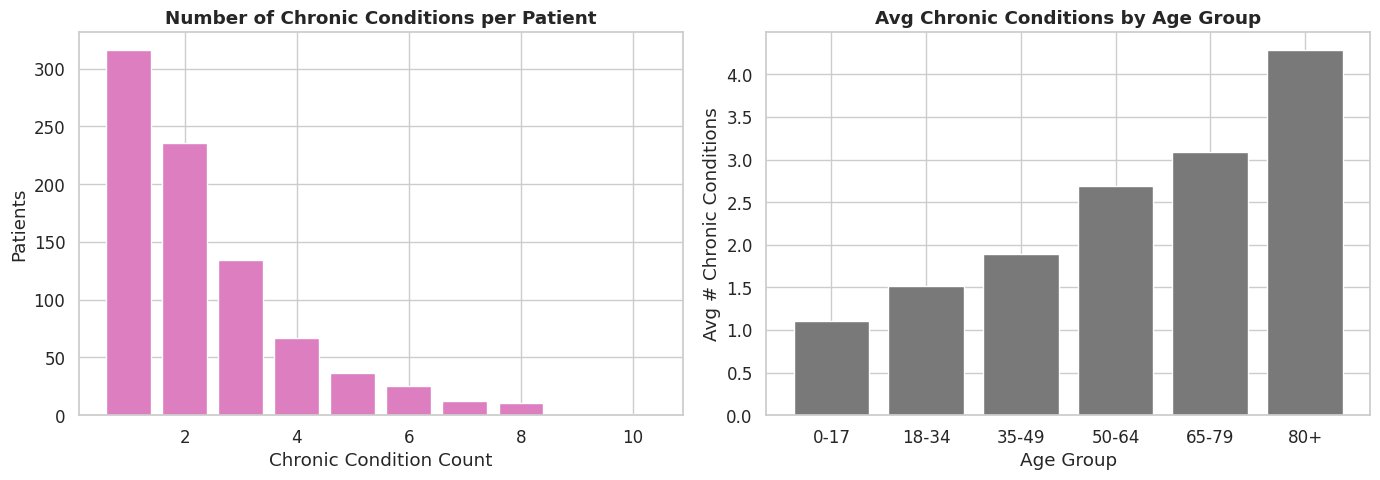

Patients with 3+ chronic conditions: 287 (34.2%)


In [21]:
# 4.5 Multimorbidity count distribution
patient_chronic_count = chronic_pts.groupby('PATIENT')['DESCRIPTION'].nunique().reset_index()
patient_chronic_count.columns = ['PATIENT', 'chronic_count']
patient_chronic_count = patient_chronic_count.merge(patients[['Id', 'AGE', 'AGE_GROUP']], left_on='PATIENT', right_on='Id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
cc = patient_chronic_count['chronic_count'].value_counts().sort_index()
axes[0].bar(cc.index, cc.values, color=COLORS[6], edgecolor='white')
axes[0].set_title('Number of Chronic Conditions per Patient')
axes[0].set_xlabel('Chronic Condition Count')
axes[0].set_ylabel('Patients')

# By age group
multi_age = patient_chronic_count.groupby('AGE_GROUP')['chronic_count'].mean()
axes[1].bar(multi_age.index.astype(str), multi_age.values, color=COLORS[7], edgecolor='white')
axes[1].set_title('Avg Chronic Conditions by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg # Chronic Conditions')

plt.tight_layout()
plt.savefig('images/23_multimorbidity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Patients with 3+ chronic conditions: {(patient_chronic_count['chronic_count'] >= 3).sum()} "
      f"({(patient_chronic_count['chronic_count'] >= 3).mean()*100:.1f}%)")


---
## 5. Population Health
Immunization coverage, medication patterns, provider capacity, and care access metrics.


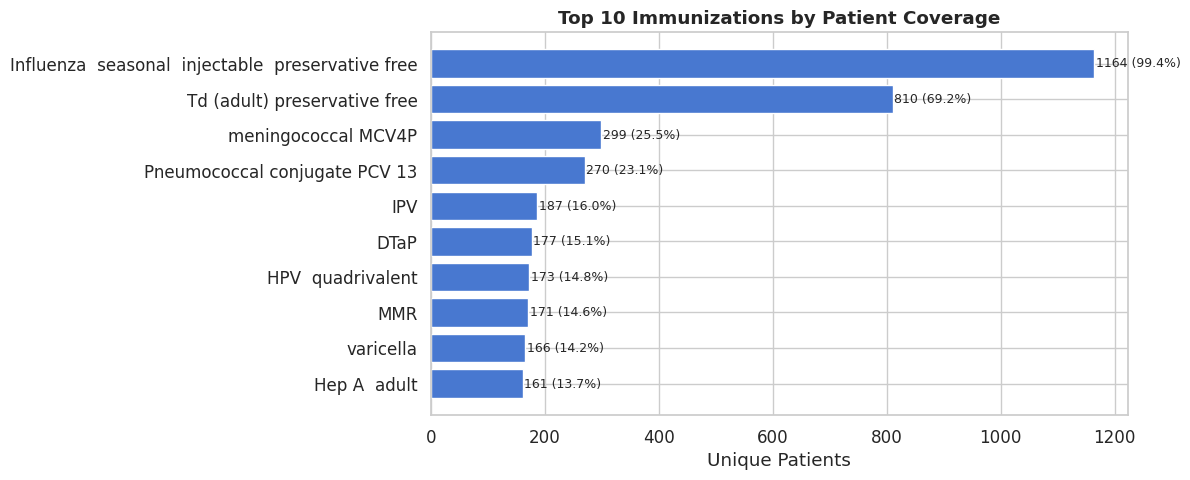

In [22]:
# 5.1 Immunization coverage — top vaccines
imm_counts = immunizations.groupby('DESCRIPTION')['PATIENT'].nunique().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(imm_counts.index[::-1], imm_counts.values[::-1], color=COLORS[0], edgecolor='white')
ax.set_title('Top 10 Immunizations by Patient Coverage')
ax.set_xlabel('Unique Patients')
for bar, val in zip(bars, imm_counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(patients)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/24_immunizations.png', dpi=150, bbox_inches='tight')
plt.show()


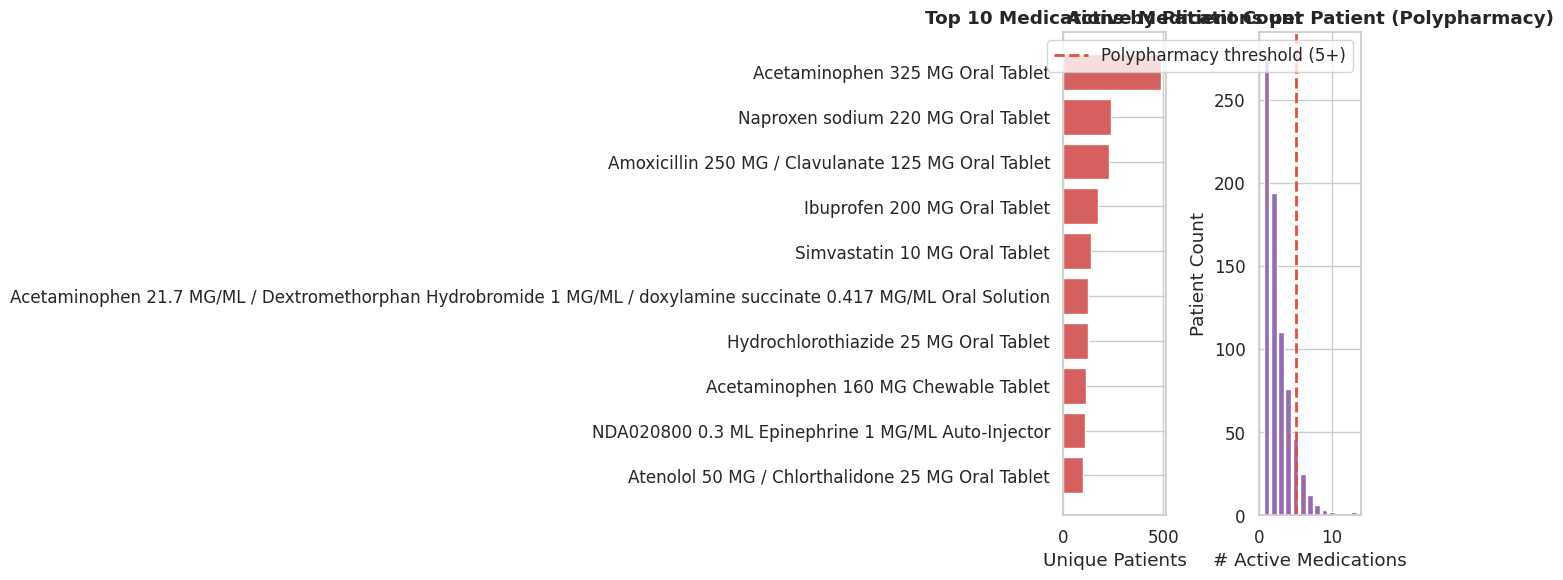

Patients with polypharmacy (5+ active meds): 97 (12.9%)


In [23]:
# 5.2 Medication analysis — top drugs & polypharmacy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top medications
med_counts = medications.groupby('DESCRIPTION')['PATIENT'].nunique().sort_values(ascending=False).head(10)
axes[0].barh(med_counts.index[::-1], med_counts.values[::-1], color=COLORS[3], edgecolor='white')
axes[0].set_title('Top 10 Medications by Patient Count')
axes[0].set_xlabel('Unique Patients')

# Polypharmacy: unique meds per patient
active_meds = medications[medications['STOP'].isna()]
poly = active_meds.groupby('PATIENT')['DESCRIPTION'].nunique().reset_index()
poly.columns = ['PATIENT', 'active_med_count']

poly_dist = poly['active_med_count'].value_counts().sort_index()
axes[1].bar(poly_dist.index, poly_dist.values, color=COLORS[4], edgecolor='white')
axes[1].set_title('Active Medications per Patient (Polypharmacy)')
axes[1].set_xlabel('# Active Medications')
axes[1].set_ylabel('Patient Count')
axes[1].axvline(5, color=HIGHLIGHT, linestyle='--', linewidth=2, label='Polypharmacy threshold (5+)')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/25_medications.png', dpi=150, bbox_inches='tight')
plt.show()

polypharmacy_pct = (poly['active_med_count'] >= 5).mean() * 100
print(f"Patients with polypharmacy (5+ active meds): {(poly['active_med_count'] >= 5).sum()} ({polypharmacy_pct:.1f}%)")


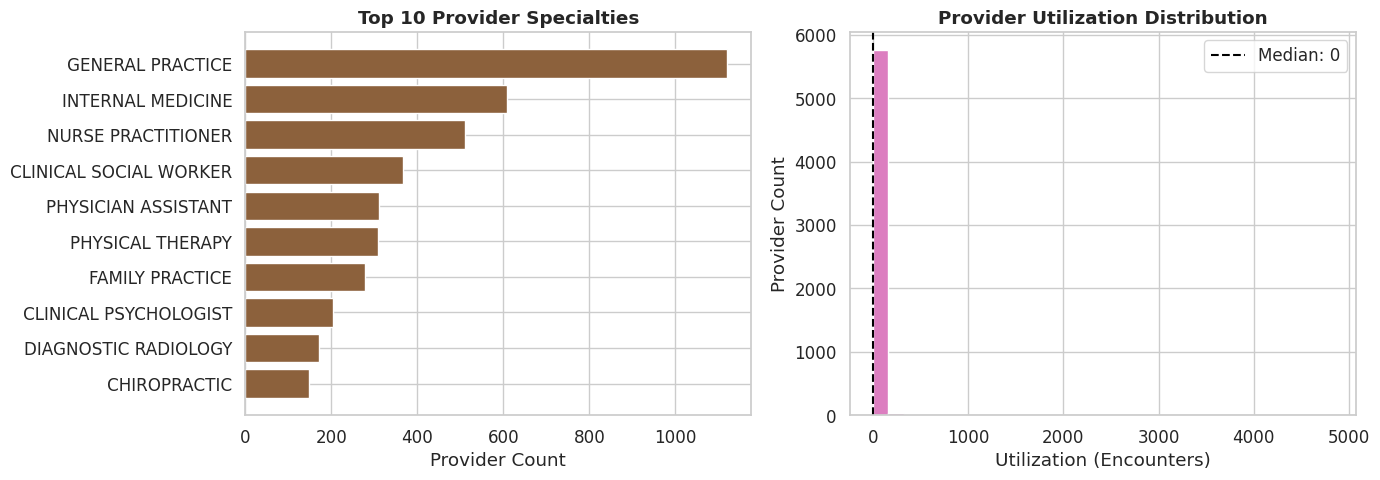

Total providers: 5,855 across 69 specialties
Provider utilization — Mean: 24 | Median: 0


In [24]:
# 5.3 Provider capacity & specialty distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top specialties
spec_counts = providers['SPECIALITY'].value_counts().head(10)
axes[0].barh(spec_counts.index[::-1], spec_counts.values[::-1], color=COLORS[5], edgecolor='white')
axes[0].set_title('Top 10 Provider Specialties')
axes[0].set_xlabel('Provider Count')

# Provider utilization distribution
axes[1].hist(providers['UTILIZATION'].dropna(), bins=30, color=COLORS[6], edgecolor='white')
axes[1].set_title('Provider Utilization Distribution')
axes[1].set_xlabel('Utilization (Encounters)')
axes[1].set_ylabel('Provider Count')
axes[1].axvline(providers['UTILIZATION'].median(), color='black', linestyle='--',
                label=f"Median: {providers['UTILIZATION'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('images/26_providers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total providers: {len(providers):,} across {providers['SPECIALITY'].nunique()} specialties")
print(f"Provider utilization — Mean: {providers['UTILIZATION'].mean():.0f} | Median: {providers['UTILIZATION'].median():.0f}")


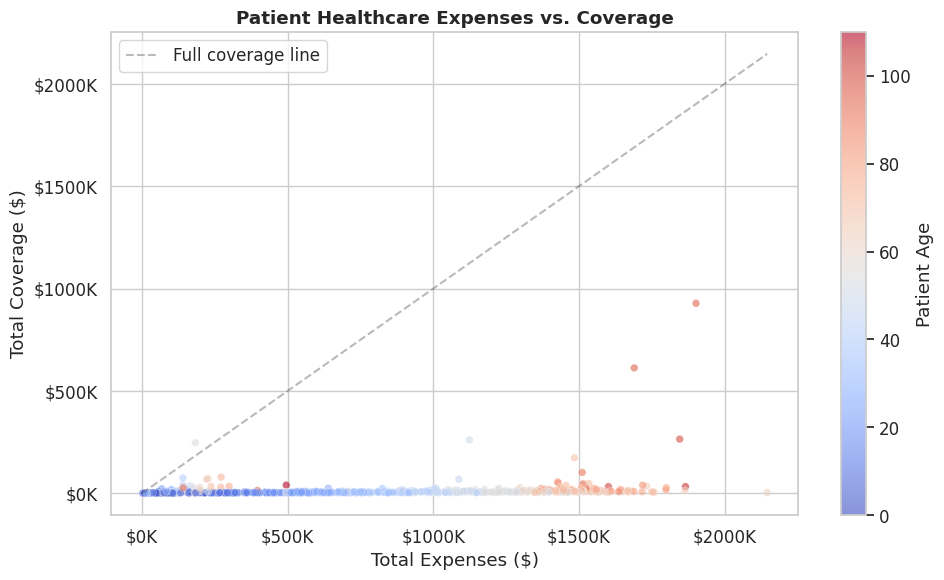

Median coverage gap: $714,768
Patients paying >50% OOP: 1168 (99.7%)


In [25]:
# 5.4 Healthcare expenses vs coverage gap (patient-level)
fig, ax = plt.subplots(figsize=(10, 6))

sample = patients.sample(min(500, len(patients)), random_state=42)
scatter = ax.scatter(sample['HEALTHCARE_EXPENSES'], sample['HEALTHCARE_COVERAGE'],
                     c=sample['AGE'], cmap='coolwarm', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
ax.plot([0, sample['HEALTHCARE_EXPENSES'].max()], [0, sample['HEALTHCARE_EXPENSES'].max()],
        'k--', alpha=0.3, label='Full coverage line')
ax.set_title('Patient Healthcare Expenses vs. Coverage')
ax.set_xlabel('Total Expenses ($)')
ax.set_ylabel('Total Coverage ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.colorbar(scatter, label='Patient Age')
ax.legend()

plt.tight_layout()
plt.savefig('images/27_expenses_vs_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Coverage gap stats
patients['COVERAGE_GAP'] = patients['HEALTHCARE_EXPENSES'] - patients['HEALTHCARE_COVERAGE']
patients['COVERAGE_GAP_PCT'] = (patients['COVERAGE_GAP'] / patients['HEALTHCARE_EXPENSES'] * 100).clip(0, 100)
print(f"Median coverage gap: ${patients['COVERAGE_GAP'].median():,.0f}")
print(f"Patients paying >50% OOP: {(patients['COVERAGE_GAP_PCT'] > 50).sum()} ({(patients['COVERAGE_GAP_PCT'] > 50).mean()*100:.1f}%)")


---
## 6. Key Findings Summary


In [26]:
# Summary statistics compilation
print("=" * 70)
print("  HEALTHCARE ANALYTICS — KEY FINDINGS SUMMARY")
print("=" * 70)

print(f"""
PATIENT DEMOGRAPHICS
  • Population: {len(patients):,} patients | {patients['IS_ALIVE'].sum()} alive, {(~patients['IS_ALIVE']).sum()} deceased
  • Median age: {patients['AGE'].median():.0f} | Range: {patients['AGE'].min()}–{patients['AGE'].max()}
  • Gender: {patients['GENDER'].value_counts().to_dict()}
  • States: {patients['STATE'].nunique()} | Counties: {patients['COUNTY'].nunique()}

HOSPITAL UTILIZATION
  • Total encounters: {len(encounters):,} across {encounters['ENCOUNTERCLASS'].nunique()} classes
  • Inpatient median LOS: {inpatient['LOS_DAYS'].median():.1f} days
  • 30-day readmission rate: {readmit_rate:.1f}%
  • Peak encounter month: {peak_month}

FINANCIAL
  • Total billed: ${encounters['TOTAL_CLAIM_COST'].sum():,.0f}
  • Median encounter cost: ${encounters['TOTAL_CLAIM_COST'].median():,.2f}
  • Median patient OOP%: {patient_oop['oop_pct'].median():.1f}%

CHRONIC DISEASE
  • Patients with ≥1 chronic condition: {conditions[conditions['IS_CHRONIC']]['PATIENT'].nunique()}
  • Patients with 3+ chronic conditions: {(patient_chronic_count['chronic_count'] >= 3).sum()}

POPULATION HEALTH
  • Polypharmacy (5+ active meds): {(poly['active_med_count'] >= 5).sum()} patients
  • Providers: {len(providers):,} across {providers['SPECIALITY'].nunique()} specialties
  • Median coverage gap: ${patients['COVERAGE_GAP'].median():,.0f}
""")


  HEALTHCARE ANALYTICS — KEY FINDINGS SUMMARY

PATIENT DEMOGRAPHICS
  • Population: 1,171 patients | 1000 alive, 171 deceased
  • Median age: 41 | Range: 0–110
  • Gender: {'F': 609, 'M': 562}
  • States: 1 | Counties: 14

HOSPITAL UTILIZATION
  • Total encounters: 53,346 across 6 classes
  • Inpatient median LOS: 1.0 days
  • 30-day readmission rate: 22.6%
  • Peak encounter month: 7

FINANCIAL
  • Total billed: $6,868,313
  • Median encounter cost: $129.16
  • Median patient OOP%: 41.0%

CHRONIC DISEASE
  • Patients with ≥1 chronic condition: 839
  • Patients with 3+ chronic conditions: 287

POPULATION HEALTH
  • Polypharmacy (5+ active meds): 97 patients
  • Providers: 5,855 across 69 specialties
  • Median coverage gap: $714,768

